# Tutorial 4: Analyzing Topographic Models

In this tutorial we explore the results of a trained MuTopia topographic model. We will:

1. Load a trained model and annotate a G-Tensor with component weights and SHAP values
2. Visualize mutational signatures (SBS spectra) for each component
3. Summarize feature importance with SHAP plots
4. Build genome-browser track views comparing predicted and observed mutation rates
5. Inspect component interactions with the feature interaction matrix

**Prerequisites:** Tutorial 3 (Training Models). You should have:
- `tutorial_data/trained_model.pkl` — a trained topographic model
- `tutorial_data/Liver.nc` — the annotated G-Tensor dataset

In [1]:
import mutopia.analysis as mu
import mutopia.plot.track_plot as tr
import matplotlib.pyplot as plt

model = mu.load_model('tutorial_data/pretrained_model.pkl')
print(model)

/Users/allen/miniconda3/envs/mutopia-model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Mutopia JIT-compiling model operations ...


SBSModel(convolution_width=1, eval_every=5, l2_regularization=0.0,
         locus_subsample=0.125, max_features=0.5, seed=110, threads=5)


## 1. Annotate the G-Tensor

`annot_data` runs all annotation steps in one call: component contributions, local variable predictions,
marginal mutation rate predictions, and SHAP feature attributions.
Set `calc_shap=True` to also compute SHAP values (takes a few minutes; increase `threads` to speed it up).

In [2]:
data = mu.gt.load_dataset('tutorial_data/Liver.nc', with_samples=False)
data = model.annot_data(data, threads=4, calc_shap=True)
print(data)

INFO     Mutopia Setting up dataset state ...
INFO     Mutopia Done ...
INFO     Mutopia Setting model to prediction mode.
Estimating contributions: 100%|██████████████████████████████████| 185/185 [00:01<00:00, 157.51it/s]
INFO     Mutopia Added key to dataset: "contributions"
INFO     Mutopia Added keys to dataset: Spectra/spectra, Spectra/interactions, Spectra/shared_effects
INFO     Mutopia Calculating SHAP values for M0 ...
INFO     Mutopia Calculating SHAP values for M1 ...
INFO     Mutopia Calculating SHAP values for M2 ...
INFO     Mutopia Calculating SHAP values for M3 ...
 20%|====                | 396/2000 [00:22<01:29]       IOStream.flush timed out

 71%|==============      | 1421/2000 [02:26<00:59]       IOStream.flush timed outIOStream.flush timed out

 81%|================    | 1617/2000 [03:10<00:45]       IOStream.flush timed out
IOStream.flush timed out
 45%|=========           | 893/2000 [01:52<02:18]       IOStream.flush timed outIOStream.flush timed out

 20%|====

## 2. Visualize Mutational Signatures

Each component learns a mutational signature — the probability distribution over SBS trinucleotide contexts.
`plot_signature_panel` shows all components side by side.

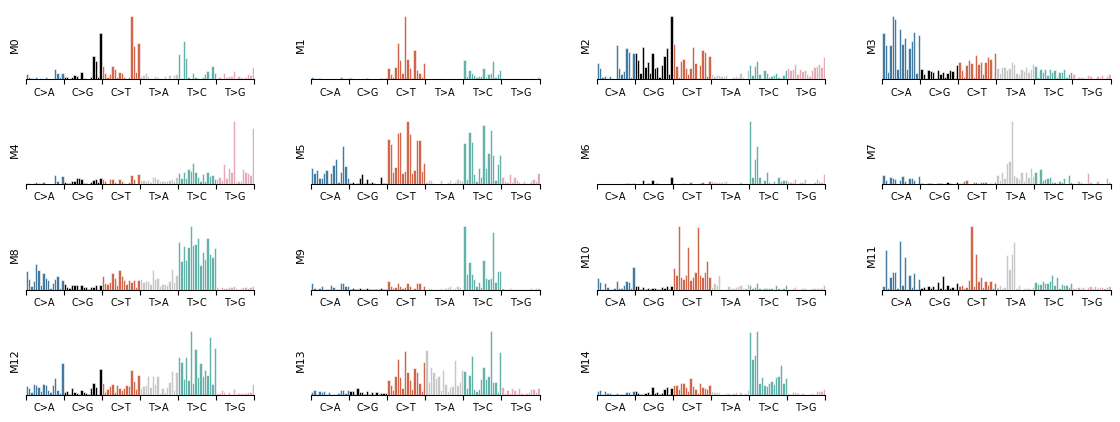

In [3]:
mu.pl.plot_signature_panel(data)

Discovered components: [np.str_('M0'), np.str_('M1'), np.str_('M2'), np.str_('M3'), np.str_('M4'), np.str_('M5'), np.str_('M6'), np.str_('M7'), np.str_('M8'), np.str_('M9'), np.str_('M10'), np.str_('M11'), np.str_('M12'), np.str_('M13'), np.str_('M14')]


<Axes: >

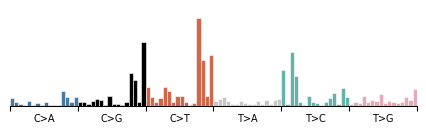

In [4]:
components = mu.gt.list_components(data)
print('Discovered components:', components)

# Zoom into a single component
mu.pl.plot_component(data, components[0])

### Strand-conditioned signatures

Pass a strand feature name to reveal transcriptional or replicational strand asymmetry.

<Axes: >

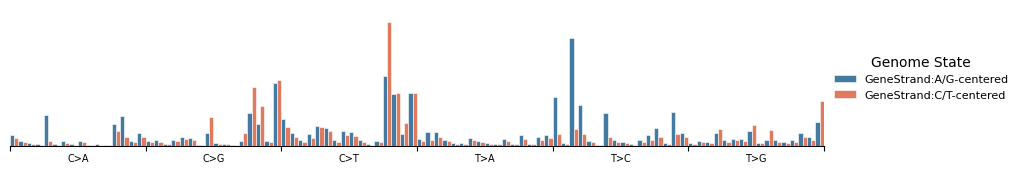

In [5]:
mu.pl.plot_component(data, components[0], 'GeneStrand')

## 3. SHAP Feature Importance

SHAP values reveal which genomic features push each locus toward or away from a component.
`plot_shap_summary` produces a beeswarm-style dot-plot: rows are features, color encodes
feature value, and horizontal position encodes impact on the log mutation rate.

<Axes: xlabel='Feature', ylabel='Component'>

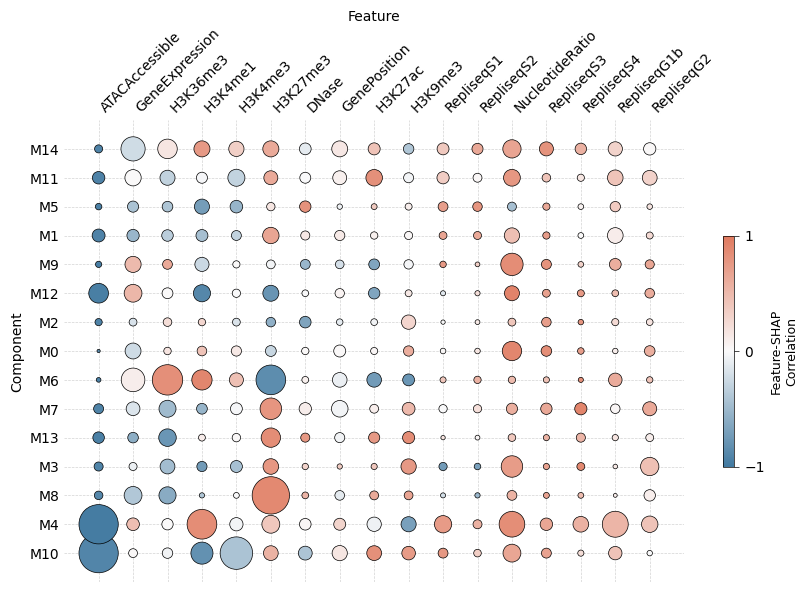

In [6]:
mu.pl.plot_shap_summary(data, scale=40, max_size=20, figsize=(10, 6))

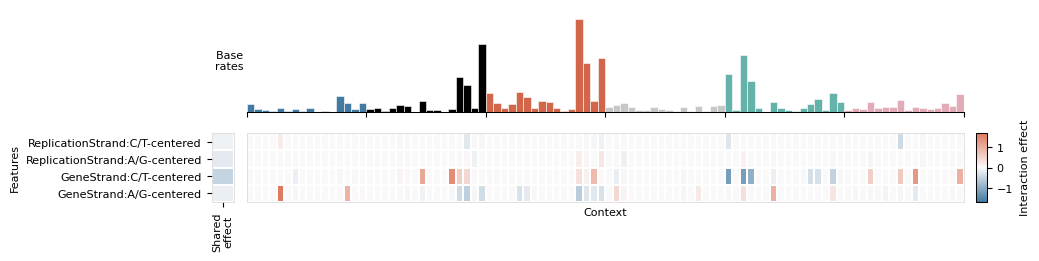

In [8]:
# Feature interaction matrix for a single component
mu.pl.plot_interaction_matrix(data, components[0])
None

## 4. Genome-Browser Track Views

The track-plot module builds composable genome-browser figures. Here we compare predicted
vs observed mutation rates and per-component rates over a 5 Mb window on chr2.

INFO     Mutopia Found 6767/388247 regions matching query.


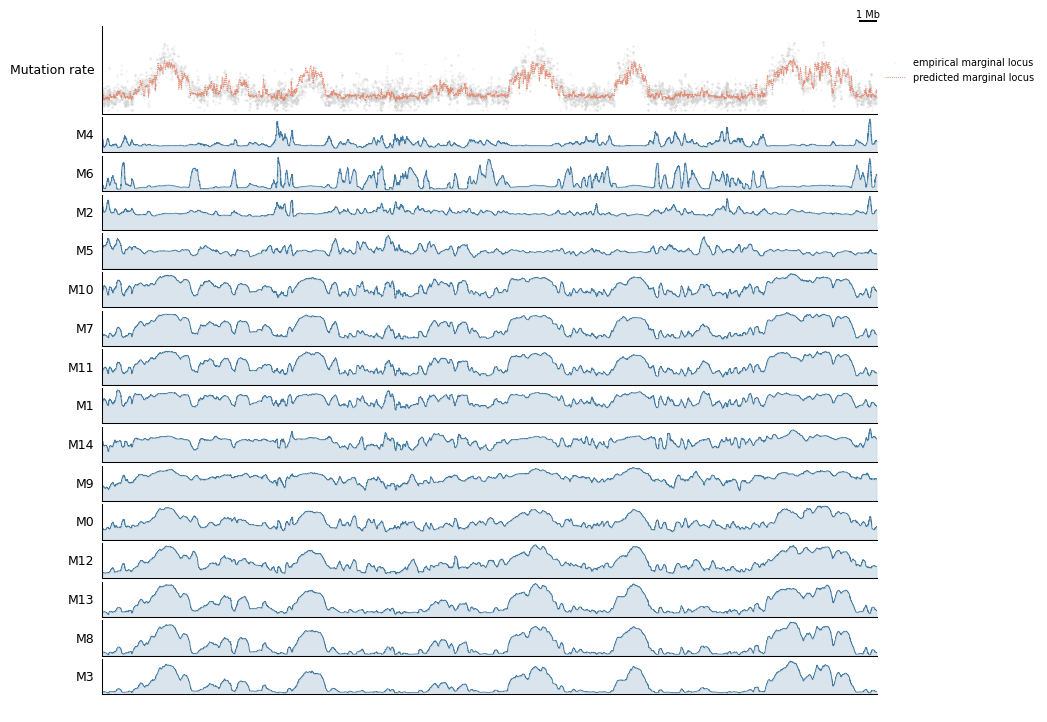

In [12]:
view = tr.make_view(data, 'chr2:10000000-55000000')

def config(view, scalebar_bp):
    return (
        tr.scale_bar(scalebar_bp, scale='mb'),
        tr.tracks.plot_marginal_observed_vs_expected(view, pred_smooth=3, smooth=3, height=1.25),
        tr.plot_component_rates(view, *tr.order_components(data)),
        tr.spacer(0.2),
    )

tr.plot_view(config, view, scalebar_bp=1_000_000, width=10)
None

## 5. Exporting SHAP Explanations

SHAP `Explanation` objects can be retrieved for downstream analysis.

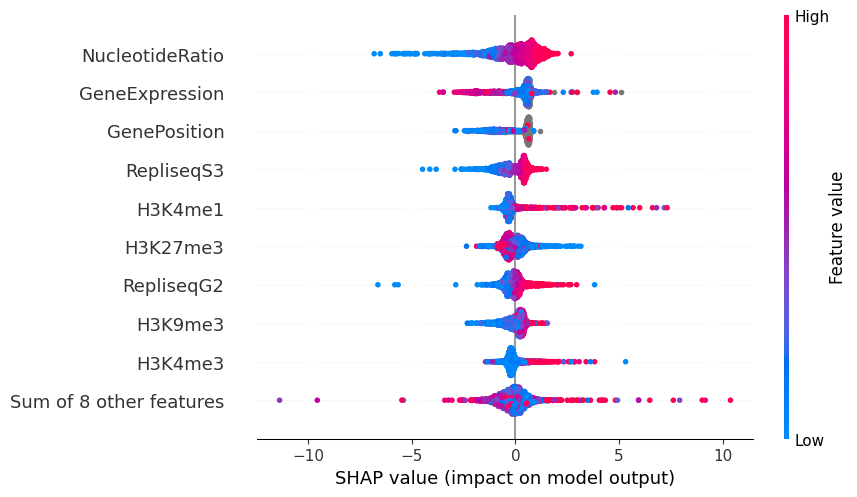

In [13]:
import shap

explanation = mu.gt.get_explanation(data, component=components[0])
shap.plots.beeswarm(explanation)

## Next steps

- **Tutorial 5: Annotating VCFs** — apply the trained model to assign each mutation in a VCF
  to a component and estimate per-sample signature fractions.
- Explore `mu.gt.rename_components` to give components biologically meaningful names.
- Try `mu.gt.slice_regions` to focus analysis on a specific gene or locus.